# Self Study 1

This self study sheet contains some code, and some questions. You should first walk through the code, and then work on the questions. The questions can be answered by extending this notebook with some additional code and text ("markdown") cells. A brief guide to formatting in markdown cells is here:<br>
https://medium.com/ibm-data-science-experience/markdown-for-jupyter-notebooks-cheatsheet-386c05aeebed<br>


The following just gives us some tools we'll need

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.svm import SVC
from scipy.stats import multivariate_normal as mvn


In [2]:
# A small utility we shall need later:
def maxpos(A):
    '''
    Takes an n x k array A, and returns 1-dim n array where the i'th
    entry is the index of column in A where the i'th row of A has its
    maximal value (application: turns a probabilitiy distribution over
    k classes for n instances into a single n-dimensional array of predictions)
    '''
    return np.argmax(A,axis=1)
    

We load the Iris dataset and inspect what it is about. Iris is probably the most heavily used dataset in machine learning. It even has its own Wikipedia page: https://en.wikipedia.org/wiki/Iris_flower_data_set

In [3]:
irisdata = load_iris()

# print(irisdata.DESCR)

The Iris data contains 4 features. In order to facillitate visualization of decision regions,
it is better to use two features only, that then can be plotted in 2D. Here we select
two features, and make a scatter plot of their values:

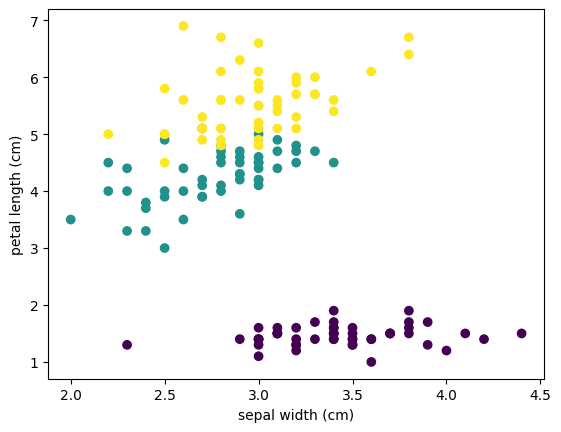

In [4]:
feat0 = 0 
feat1 = 1
feat2 = 2
feat3 = 3
plt.scatter(irisdata.data[:,feat1],irisdata.data[:,feat2],c=irisdata.target)
plt.xlabel(irisdata['feature_names'][feat1])
plt.ylabel(irisdata['feature_names'][feat2])
plt.show()

We next define and train several classification models. We continue to only use the first two features of the data.

First, the **K nearest neighbor** model. To define the model, we have to select the value of K, here called n_neighbors. The .fit function is the generic function for model training. For the K nearest neighbor model there is no actual training, however. 

In [5]:
irisknn = KNeighborsClassifier(n_neighbors=6)
irisknn.fit(irisdata.data[:,[feat1,feat2]],irisdata.target)


,n_neighbors,6
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


# The following defines three different linear models
- Linear regression is the same as 'Least squares regression on the slides of the first lecture;
- logistic regression
- linear support vector machine

Logistic and Linear support vector will be studied in more detail in the following lectures. 

For now we need to know that for each of the models we first specify the desired model class, and then *fit* (or 'train', or 'learn') the model based on our labeled training data. 

The linear regression model requires the label information in a different format from the other two models, which is why we first construct the 'one hot encoding' representation. 

After the models have been fitted, they each define a linear decision boundary, and can classify unlabeled examples. 

In [6]:
onehotclasses = np.zeros((irisdata.target.size,3))
for i in range(irisdata.target.size): 
    onehotclasses[i][irisdata.target[i]]=1.0
  
irislinreg = LinearRegression()
irislinreg.fit(irisdata.data[:,[feat1,feat2]],onehotclasses)

irislogreg = LogisticRegression()
irislogreg.fit(irisdata.data[:,[feat1,feat2]],irisdata.target)

irislinsvc = SVC(kernel='linear')
irislinsvc.fit(irisdata.data[:,[feat1,feat2]],irisdata.target)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Plotting labelled data points and decision regions. 

First, a meshgrid is constructed consisting of a fine grid of points that we classify, and then use for visualisation of the decision regions. 

Then, our classifier is applied to the grid (uncomment the pair of lines you want for either knn or one of the linear models).


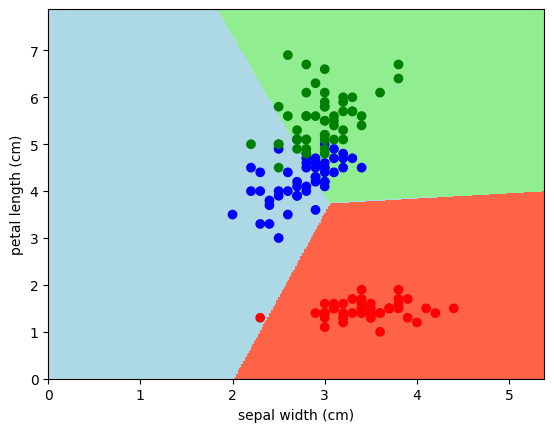

In [7]:
# maximal values found in the data for the two selected features
# Used to adjust the ranges of axes in the plot
maxval1 = np.max(irisdata.data[:,feat1])
maxval2 = np.max(irisdata.data[:,feat2])

# The np.meshgrid function takes two array arguments: x-array,y-array of sizes x-numpoints and y-numpoints, respectively.
# We created these arrays using np.arange.
# It returns two two-dimensional arrays of size (x-numpoints x y-numpoints), where xx contains the x-coordinates of all pairs of points with
# an x coordinate in x-array, and a y-coordinate in y-array. Similarly, yy contains the corresponding y-coordinates
xx, yy = np.meshgrid(np.arange(0, maxval1+1, 0.02), np.arange(0, maxval2+1, 0.02))

# With np.c_[xx.ravel(),yy.ravel()] we create an (x-numpoints * y-numpoints)x2 - dimensional array that simply contains all 
# (x,y) pairs with x in x-array and y in y-array

# Uncomment one of the following to select a classification model:

# Z = irisknn.predict(np.c_[xx.ravel(), yy.ravel()])

Z = irislinreg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = maxpos(Z) # Here we have to turn the vector returned by LinearRegression into a categorical prediction

# Z = irislogreg.predict(np.c_[xx.ravel(), yy.ravel()])

# Z = irislinsvc.predict(np.c_[xx.ravel(), yy.ravel()])

# Z is the vector of predictions of length x-numpoints * y-numpoints. We reshape it back into a 2-dimensional array:

Z = Z.reshape(xx.shape)
plt.contourf(xx,yy,Z,[-0.5,0.5,1.5,2.5],colors=('tomato','lightblue','lightgreen'))
plt.scatter(irisdata.data[:,feat1],irisdata.data[:,feat2],c=irisdata.target, cmap = mpl.colors.ListedColormap(['r', 'b', 'g']))
plt.xlabel(irisdata['feature_names'][feat1])
plt.ylabel(irisdata['feature_names'][feat2])
plt.show()

**Exercise 1** Visualize and describe the decision boundaries obtained from the KNN classifier and the linear regression classifier. Use different values of K in the KNN classifier, and also consider different selections of predictive features. This does not require any extension of the code.

**Answer**: 
For the KNN classifier:
I trained the model using different values of K, such as:

K = 1
K = 3
K = 6

With lower neighbour the the shape is smooter and the decision boundaries match the shape of the classes.

For the linear regression if is used another feature combination of f1 and f2 the result is completely wrong.

**Exercise 2:** Divide the data into 70% training and 30% test data. Learn KNN and linear regression classifiers from the training data, and evaluate their accuracy both on the training and test data. For the KNN classifier,
draw the curves that show train/test accuracy as a function of K. Useful sklearn functions:<br>
`sklearn.model selection.train test split`<br>
`sklearn.metrics.accuracy score`<br>
`sklearn.metrics.confusion matrix`

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd

# Divide data into 70% training and 30% test data
# Using only the two features for now (matching the previous exercises)
X = irisdata.data[:,[feat1,feat2]]
y = irisdata.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 105
Test set size: 45


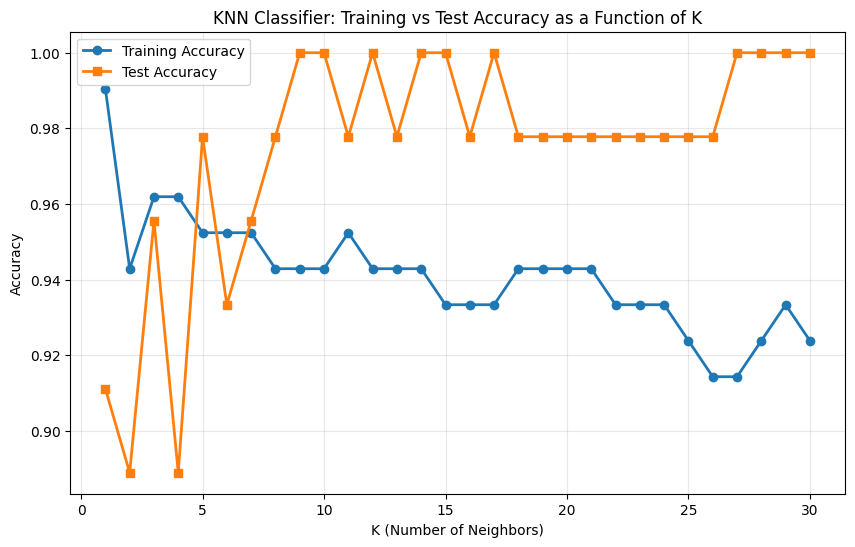


KNN Classifier Accuracies:
--------------------------------------------------
K =  1: Train Accuracy = 0.9905, Test Accuracy = 0.9111
K =  3: Train Accuracy = 0.9619, Test Accuracy = 0.9556
K =  5: Train Accuracy = 0.9524, Test Accuracy = 0.9778
K = 10: Train Accuracy = 0.9429, Test Accuracy = 1.0000
K = 15: Train Accuracy = 0.9333, Test Accuracy = 1.0000
K = 20: Train Accuracy = 0.9429, Test Accuracy = 0.9778
K = 30: Train Accuracy = 0.9238, Test Accuracy = 1.0000


In [9]:
# Train KNN classifiers with varying K values and collect accuracies
K_values = range(1, 31)  # K from 1 to 30
train_accuracies = []
test_accuracies = []

for k in K_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    # Predictions on training and test data
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)
    
    # Calculate accuracies
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plot the curves
plt.figure(figsize=(10, 6))
plt.plot(K_values, train_accuracies, marker='o', label='Training Accuracy', linewidth=2)
plt.plot(K_values, test_accuracies, marker='s', label='Test Accuracy', linewidth=2)
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN Classifier: Training vs Test Accuracy as a Function of K')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print the accuracies for some key K values
print("\nKNN Classifier Accuracies:")
print("-" * 50)
for k in [1, 3, 5, 10, 15, 20, 30]:
    train_acc = train_accuracies[k-1]
    test_acc = test_accuracies[k-1]
    print(f"K = {k:2d}: Train Accuracy = {train_acc:.4f}, Test Accuracy = {test_acc:.4f}")


In [10]:
# Train Linear Regression classifier
# Prepare one-hot encoding for training data
onehotclasses_train = np.zeros((y_train.size, 3))
for i in range(y_train.size):
    onehotclasses_train[i][y_train[i]] = 1.0

# Train the linear regression model
linreg = LinearRegression()
linreg.fit(X_train, onehotclasses_train)

# Make predictions on training and test data
y_train_pred_linreg = maxpos(linreg.predict(X_train))
y_test_pred_linreg = maxpos(linreg.predict(X_test))

# Calculate accuracies
train_acc_linreg = accuracy_score(y_train, y_train_pred_linreg)
test_acc_linreg = accuracy_score(y_test, y_test_pred_linreg)

print("\n" + "="*50)
print("Linear Regression Classifier:")
print("="*50)
print(f"Training Accuracy: {train_acc_linreg:.4f}")
print(f"Test Accuracy:     {test_acc_linreg:.4f}")

# Display confusion matrices for linear regression
print("\n" + "-"*50)
print("Confusion Matrix - Training Data:")
print("-"*50)
cm_train_linreg = confusion_matrix(y_train, y_train_pred_linreg)
print(cm_train_linreg)

print("\n" + "-"*50)
print("Confusion Matrix - Test Data:")
print("-"*50)
cm_test_linreg = confusion_matrix(y_test, y_test_pred_linreg)
print(cm_test_linreg)



Linear Regression Classifier:
Training Accuracy: 0.8000
Test Accuracy:     0.8000

--------------------------------------------------
Confusion Matrix - Training Data:
--------------------------------------------------
[[30  1  0]
 [ 0 21 16]
 [ 0  4 33]]

--------------------------------------------------
Confusion Matrix - Test Data:
--------------------------------------------------
[[19  0  0]
 [ 0  5  8]
 [ 0  1 12]]


**Exercise 3:**  Also perform (some) of the previous experiments using the full set of 4 predictive features. How does that
change the classification performance? Which of the 3 Iris classes is easiest to classify? Why?

In [11]:
# Exercise 3: Using all 4 features
# Split data with all 4 features
X_all_features = irisdata.data[:,[feat0,feat1,feat2,feat3]]
y = irisdata.target

X_train_4f, X_test_4f, y_train_4f, y_test_4f = train_test_split(
    X_all_features, y, test_size=0.3, random_state=42)

# Train KNN with 4 features
print("="*60)
print("KNN Classifier - 2 Features vs 4 Features Comparison")
print("="*60)

knn_2f = KNeighborsClassifier(n_neighbors=3)
knn_2f.fit(X_train[:,:2], y_train)
acc_2f = accuracy_score(y_test, knn_2f.predict(X_test[:,:2]))

knn_4f = KNeighborsClassifier(n_neighbors=3)
knn_4f.fit(X_train_4f, y_train_4f)
acc_4f = accuracy_score(y_test_4f, knn_4f.predict(X_test_4f))

print(f"KNN (2 features) Test Accuracy: {acc_2f:.4f}")
print(f"KNN (4 features) Test Accuracy: {acc_4f:.4f}")

# Train Linear Regression with 4 features
onehotclasses_train_4f = np.zeros((y_train_4f.size, 3))
for i in range(y_train_4f.size):
    onehotclasses_train_4f[i][y_train_4f[i]] = 1.0

linreg_4f = LinearRegression()
linreg_4f.fit(X_train_4f, onehotclasses_train_4f)

y_test_pred_4f = maxpos(linreg_4f.predict(X_test_4f))
acc_4f_linreg = accuracy_score(y_test_4f, y_test_pred_4f)

print(f"\nLinear Regression (4 features) Test Accuracy: {acc_4f_linreg:.4f}")

# Confusion matrix to identify easiest class
print("\n" + "-"*60)
print("Confusion Matrix (4 features):")
print("-"*60)
cm = confusion_matrix(y_test_4f, y_test_pred_4f)
print(cm)
print("\nClass names: 0=Setosa, 1=Versicolor, 2=Virginica")

KNN Classifier - 2 Features vs 4 Features Comparison
KNN (2 features) Test Accuracy: 0.9556
KNN (4 features) Test Accuracy: 1.0000

Linear Regression (4 features) Test Accuracy: 0.8222

------------------------------------------------------------
Confusion Matrix (4 features):
------------------------------------------------------------
[[19  0  0]
 [ 0  6  7]
 [ 0  1 12]]

Class names: 0=Setosa, 1=Versicolor, 2=Virginica


We now leave the Iris data behind, and consider a synthetic example of a dataset that is linearly separable, but 
for which many classifiers may end up making at least one wrong prediction (and perhaps for a good reason):

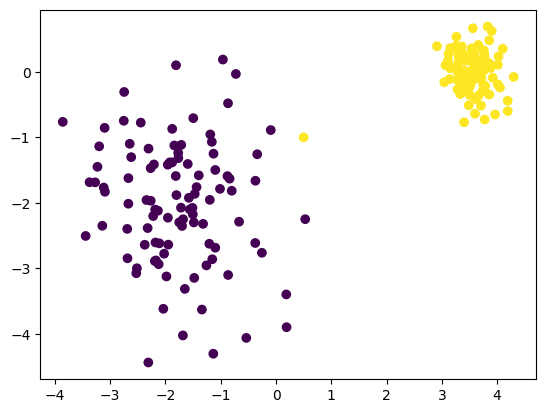

In [12]:
gauss1= mvn(mean=(-2,-2),cov=((1,0),(0,1))).rvs(random_state=1,size=100)
gauss2= mvn(mean=(3.5,0),cov=((0.1,0),(0,0.1))).rvs(random_state=1,size=100)
X=np.vstack([gauss1,gauss2])
X=np.vstack([X,(0.5,-1)])
Y=np.hstack([np.zeros(100),np.ones(101)])

plt.scatter(X[:,0],X[:,1],c=Y)
plt.show()

Prepare a meshgrid for the visualization of decision regions:


In [13]:
leftx=np.min(X[:,0])-0.5
rightx=np.max(X[:,0])+0.5
lefty=np.min(X[:,1])-0.5
righty=np.max(X[:,1])+0.5

xx, yy = np.meshgrid(np.arange(leftx, rightx, 0.02), np.arange(lefty, righty, 0.02))

**Exercise 4**: Can you find classifiers that classify the yellow 'outlier' point as purple, and another one that classifies it as yellow (and also classifies all other points correctly)?

Classifier 1 predicts outlier as class: 0.4418564363257781


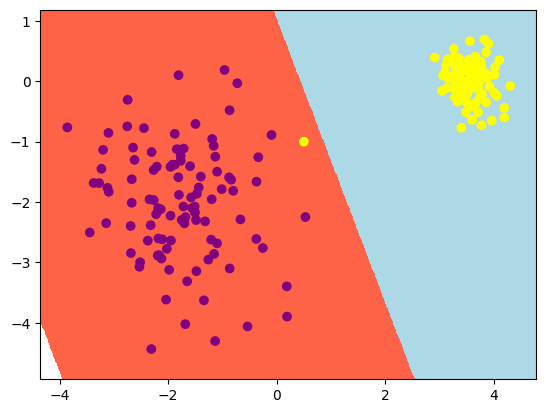

In [14]:
# knn = KNeighborsClassifier(n_neighbors=1)
# knn.fit(X, Y)
# Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
# Z = Z.reshape(xx.shape)

# outlier_pred_knn = knn.predict([[0.5, -1]])
# print(f"Classifier 1 predicts outlier as class: {outlier_pred_knn[0]}")

lr = LinearRegression()
lr.fit(X, Y)
Z = lr.predict(np.c_[xx.ravel(), yy.ravel()])
Z = np.round(Z)
Z = Z.reshape(xx.shape)
outlier_pred_lr = lr.predict([[0.5, -1]])
print(f"Classifier 1 predicts outlier as class: {outlier_pred_lr[0]}")

plt.contourf(xx,yy,Z,[-0.5,0.5,1.5],colors=('tomato','lightblue'))
plt.scatter(X[:, 0],X[:, 1], c=Y, cmap = mpl.colors.ListedColormap(['purple', 'yellow']))
plt.show()